<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h1>Homework, Task 2: Clean and pre-process the data</h1>

Task 1 explored the repeat-purchase data and left a list of open decisions. This notebook takes them in the order of the task statement. It handles missing values and implausible observations, deals with the categorical variables, decides whether to integrate clientes.csv, reviews the variables and adds features, and applies scaling. Every choice is justified, and findings from Task 1 are referred to but not repeated.


<h2>Contents</h2>

<p>The sections follow the order of the task statement.</p>

<ol>
  <li><a href="#setup">Setup and import</a></li>
  <li><a href="#quality">Missing values and anomalous or implausible observations</a></li>
  <li><a href="#categorical">Categorical variables</a></li>
  <li><a href="#clientes">The optional table clientes.csv</a></li>
  <li><a href="#features">Review of the supplied variables and additional features</a></li>
  <li><a href="#scaling">Scaling</a></li>
  <li><a href="#pipeline">Reproducible pre-processing without test.csv</a></li>
  <li><a href="#summary">Summary of decisions</a></li>
</ol>

</div>

<a id="setup"></a>
<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h2>1. Setup and import</h2>

<p>The notebook reads train.csv and clientes.csv from the same data folder as Task 1. RANDOM STATE fixes every random choice, so a rerun gives the same numbers.</p>

</div>

In [1]:
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.tree import DecisionTreeClassifier

pd.set_option("display.max_columns", None)   # show every column, no "..." in wide tables
pd.set_option("display.max_colwidth", None)  # show long labels in full, no "..." at the end
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#8a8984"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)  # for reproducibility
TARGET = "repeat_purchase_90d"
SENTINEL = 1e8          # anything at or above this is the 1e9 placeholder code
TOL = 0.01              # tolerance for accounting identities (amounts are rounded to cents)

# Convergence and one-hot warnings are silenced once here. Their source is known and expected.
warnings.filterwarnings("ignore")


LABELS = {
    "Total a Pagar": "Total Payable", "Total Bruto": "Gross Total", "Total Liquido": "Net Total",
    "Total Imp_": "Total Tax", "Total Portes": "Shipping Cost", "Total Desc_ Global": "Global Discount",
    "Total Desc_ Linha": "Line Discount", "Custo": "Cost", "N_ Detalhes": "Number of Lines",
    "invoice_count_current_purchase": "Invoices in Purchase", TARGET: "Repeat Purchase 90 Days",
    "customer_id": "Customer ID", "prior_std_purchase_value": "Prior Std of Purchase Value",
    "prior_std_gap_days": "Prior Std of Gap Days",
    "typical_gap_le_90": "Typical Gap up to 90 Days", "share_90_of_365": "Share of 90 in 365 Days",
    "vat_rate": "VAT Rate", "is_first_purchase": "First Purchase Flag", "has_gap_history": "Gap History Flag",
    "zero_cost": "Zero Cost Flag", "has_shipping": "Shipping Flag",
}
SMALL_WORDS = {"or", "of", "in", "to", "per", "vs"}

# English display label without underscores, e.g. payment_type -> Payment Type, spend_30d -> Spend 30 Days.
def nice(name):
    if name in LABELS:
        return LABELS[name]
    name = str(name).replace("infrequent_sklearn", "Infrequent")
    for col in sorted(LABELS, key=len, reverse=True):   # one-hot names start with the column name
        if name.startswith(col + "_"):
            return LABELS[col] + " " + name[len(col) + 1:]
    words = re.sub(r"(\d+)d\b", r"\1 Days", name).replace("_", " ").split()
    return " ".join(w if w.isupper() or w[0].isdigit() or w in SMALL_WORDS else w[0].upper() + w[1:] for w in words)

print("scikit-learn", sklearn.__version__, "| pandas", pd.__version__)

scikit-learn 1.9.1 | pandas 3.0.5


In [2]:
DATA_DIR = Path.home() / "Downloads" / "Project" / "data"
if not DATA_DIR.exists():  # fall back to a data folder next to the notebook
    DATA_DIR = Path("data")

train_raw = pd.read_csv(DATA_DIR / "train.csv")
clientes = pd.read_csv(DATA_DIR / "clientes.csv")

pd.DataFrame(
    {name: {"Rows": df.shape[0], "Columns": df.shape[1]}
     for name, df in [("Train (train.csv)", train_raw), ("Customer Table (clientes.csv)", clientes)]}
).T

,Rows,Columns
Train (train.csv),6534,39
Customer Table (clientes.csv),1143,13


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>1.1 How the data is prepared</h3>

<p>Every pre-processing step in this notebook belongs to one of two kinds, and the difference decides where it may run.</p>

<table>
  <tr><th>Kind</th><th>Example</th><th>Learns from Data</th><th>Treatment of Train and Test</th></tr>
  <tr><td><b>Rule</b> (stateless)</td><td>replace the 1e9 code by a missing value, mean = total / count, log1p</td><td>no</td><td>the same function is applied row by row, and a row's result depends on that row only</td></tr>
  <tr><td><b>Fitted</b> (stateful)</td><td>a median used for imputation, the list of category levels, the mean and standard deviation of a scaler</td><td>yes</td><td>fit on the training rows only, then transform on any rows</td></tr>
</table>

<p>As in the practicals, every fitted step is a function that receives a training frame and a test frame, fits on the training frame and only transforms the test frame (fill missing in Week 3, fold matrices in Week 4). Rules can never leak information, because they do not look at other rows. Section 7 puts all steps into one such function, which is refitted on the training part of every split, and in Task 4 it is fitted once on train.csv and only applied to test.csv.</p>

<p>Several decisions are taken by <b>comparing alternatives on held-out rows of train</b>, like the benchmarks in the practicals. The splits are five folds of StratifiedGroupKFold from the Week 5 practical. They are stratified by the target, as the lecture recommends for classification, and grouped by Customer ID, because Task 1 showed that rows of the same customer are strongly related (35% of the target variance lies between customers), and a random split would put the same customer on both sides and overstate every score. The comparison uses the two models of the practicals, a logistic regression and a decision tree limited to depth 5, scored by ROC AUC, the probability that a random repeat row gets a higher score than a random non-repeat row. Choosing and tuning the final model is Task 4.</p>

</div>

<a id="quality"></a>
<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h2>2. Missing values and anomalous or implausible observations</h2>

<p>This section follows the first sentence of the task. It removes rows without information, repairs implausible values and then handles the missing values that remain. The repair comes before the missing values on purpose, because it closes most of the gaps.</p>

<h3>2.1 Rows that carry no information</h3>

<p>Task 1 (Sections 5.1 and 5.2) found 65 rows in which every feature is missing, with a repeat rate of 0.508 against 0.559 overall, and no duplicated purchases. These findings are not repeated here. The code only marks the empty rows again so they can be dropped.</p>

</div>

In [3]:
IDENTIFIERS = ["ID", "customer_id"]
feature_cols = [c for c in train_raw.columns if c not in IDENTIFIERS + [TARGET]]
empty = train_raw[feature_cols].isna().all(axis=1)   # the 65 empty rows of Task 1, Section 5.1

train = train_raw.loc[~empty].reset_index(drop=True)
X = train.drop(columns=[TARGET])
y = train[TARGET]
groups = train["customer_id"]
print(f"Training rows kept: {len(train):,} of {len(train_raw):,} | customers: {groups.nunique()} | "
      f"repeat rate {y.mean():.4f}")

Training rows kept: 6,469 of 6,534 | customers: 607 | repeat rate 0.5597


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Decision</b></p>

<p>The 65 empty rows are dropped from the training data. They contain no feature at all, so a model can learn nothing from them, and any value they received by imputation would be invented. Their repeat rate is close to the overall rate, so removing them hardly shifts the class balance, and 6,469 rows from 607 customers remain.</p>

<p><b>Dropping is a training-only step.</b> At prediction time every ID in test.csv needs a prediction, so no test row may be dropped. The pre-processing therefore does not drop rows itself, and a row whose features are all missing is filled by its median safety net, which Section 7.3 checks explicitly. The drop happens once, here, before anything is fitted.</p>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>2.2 Anomalous and implausible values</h3>

<p>An <b>implausible</b> value breaks a rule that follows from what the column means, for example an amount cannot be negative and a mean lies between the minimum and the maximum. An <b>extreme</b> value is large but possible. Implausible values are errors and are repaired or set to missing, while extreme values are kept (Section 2.5).</p>

<p>Task 1 (Sections 5.4 and 5.5) already counted the implausible values. They all sit in the history block, as 1e9 placeholder codes, &minus;4 day codes, flipped signs and inflated values, while the invoice block is fully consistent. The rules are written here once more as a boolean check, not to repeat the counts but so that the same list can be checked after the repair in Section 2.4. In the rule names k stands for Prior Purchase Count and T for Prior Total Spend.</p>

</div>

In [4]:
def rule_violations(df):
    k, T = df["prior_purchase_count"], df["prior_total_spend"]
    mean, mx = df["prior_mean_purchase_value"], df["prior_max_purchase_value"]
    s365 = df["spend_365d"]
    rules = {
        "Placeholder 1e9 in Prior Mean Purchase Value": mean >= SENTINEL,
        "Placeholder 1e9 in Spend 365 Days": s365 >= SENTINEL,
        "Negative Prior Mean Purchase Value": mean < 0,
        "Negative Spend 365 Days": s365 < 0,
        "Negative Days Since Previous Purchase (−4)": df["days_since_previous_purchase"] < 0,
        "Negative Prior Mean Gap Days (−4)": df["prior_mean_gap_days"] < 0,
        "Prior Mean ≠ T / k": (mean.between(0, SENTINEL)) & (k > 0) & ~np.isclose(mean, T / k.where(k > 0), atol=TOL),
        "Prior Max Purchase Value > T": mx > T + TOL,
        "Spend 365 Days > T": s365.between(0, SENTINEL) & (s365 > T + TOL),
        "Spend 365 Days < Spend 180 Days": s365.between(0, SENTINEL) & (s365 < df["spend_180d"] - TOL),
        "Days Since Previous Purchase > Customer Tenure Days": df["days_since_previous_purchase"] > df["customer_tenure_days"],
        "Window Counts Not Nested (30 ≤ 90 ≤ 180 ≤ 365 Days ≤ k)": (
            (df["purchase_count_30d"] > df["purchase_count_90d"]) | (df["purchase_count_90d"] > df["purchase_count_180d"])
            | (df["purchase_count_180d"] > df["purchase_count_365d"]) | (df["purchase_count_365d"] > k)),
        "Total Payable ≠ Net Total + Total Tax": ~np.isclose(df["Total a Pagar"], df["Total Liquido"] + df["Total Imp_"], atol=0.02),
        "Net Total ≠ Gross Total − Line Discount − Global Discount": ~np.isclose(
            df["Total Liquido"], df["Total Bruto"] - df["Total Desc_ Linha"] - df["Total Desc_ Global"], atol=0.02),
        "Cost above Net Total (Sale below Cost)": df["Custo"] > df["Total Liquido"],
    }
    return pd.Series({name: int(mask.sum()) for name, mask in rules.items()}, name="Rows Violating").rename_axis("Rule")

violations_before = rule_violations(X)

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>2.3 Can the broken values be recovered?</h3>

<p>Several history columns are linked by exact identities. If an identity holds on the clean rows, a broken value can be <b>recomputed</b> instead of imputed, which is better than any estimate. Each identity is tested on the rows where all its inputs are plausible.</p>

</div>

In [5]:
k, T = X["prior_purchase_count"], X["prior_total_spend"]
ten, ds, gap = X["customer_tenure_days"], X["days_since_previous_purchase"], X["prior_mean_gap_days"]
mean, mx, s365 = X["prior_mean_purchase_value"], X["prior_max_purchase_value"], X["spend_365d"]
c365, c180, s180 = X["purchase_count_365d"], X["purchase_count_180d"], X["spend_180d"]
plausible_mean = mean.between(0, SENTINEL) & (k > 0)
plausible_s365 = s365.between(0, SENTINEL)

def share(mask, holds):
    return {"Identity Holds (%)": round(100 * holds[mask].mean(), 2), "Rows Tested": int(mask.sum())}

identities = {
    "Prior Mean = T / k": share(plausible_mean, np.isclose(mean, T / k.where(k > 0), atol=TOL)),
    "k = 1, Days Since Previous Purchase = Customer Tenure Days": share((k == 1) & (ds >= 0), ds == ten),
    "k = 1, Prior Min = Prior Max = T": share(k == 1, np.isclose(X["prior_min_purchase_value"], T) & np.isclose(mx, T)),
    "k ≥ 2, Prior Mean Gap = (Tenure − Days Since Previous) / (k − 1)": share(
        (k >= 2) & (ds >= 0) & (gap >= 0), np.isclose(gap, (ten - ds) / (k - 1), atol=TOL)),
    "Count 365 Days = 0, Spend 365 Days = 0": share(plausible_s365 & (c365 == 0), s365 == 0),
    "Count 365 Days = Count 180 Days, Spend 365 Days = Spend 180 Days": share(plausible_s365 & (c365 == c180), np.isclose(s365, s180, atol=TOL)),
    "Count 365 Days = k, Spend 365 Days = T": share(plausible_s365 & (c365 == k), np.isclose(s365, T, atol=TOL)),
}
pd.DataFrame(identities).T.astype({"Rows Tested": int}).rename_axis("Identity")

,Identity Holds (%),Rows Tested
Identity,,
Prior Mean = T / k,99.180,5640
"k = 1, Days Since Previous Purchase = Customer Tenure Days",100.000,423
"k = 1, Prior Min = Prior Max = T",99.330,445
"k ≥ 2, Prior Mean Gap = (Tenure − Days Since Previous) / (k − 1)",100.000,5031
"Count 365 Days = 0, Spend 365 Days = 0",100.000,810
"Count 365 Days = Count 180 Days, Spend 365 Days = Spend 180 Days",99.500,1801
"Count 365 Days = k, Spend 365 Days = T",99.180,1717


In [6]:
# How were the inflated and negative values produced?
inflated_mean = plausible_mean & ~np.isclose(mean, T / k.where(k > 0), atol=TOL)
negative_mean = mean < 0
inflated_s365 = plausible_s365 & (s365 > T + TOL)
negative_s365 = s365 < 0

def factor_range(ratio):
    return ratio.describe()[["min", "50%", "max"]].round(1).set_axis(["Min", "Median", "Max"])

display(pd.DataFrame({
    "Inflated Prior Mean, Factor Mean / (T / k)": factor_range((mean / (T / k))[inflated_mean]),
    "Inflated Prior Max, Factor Max / T": factor_range((mx / T)[mx > T + TOL]),
    "Inflated Spend 365 Days, Factor Spend / T": factor_range((s365 / T)[inflated_s365]),
}).T.rename_axis("Inflated Values"))
print(f"Negative means whose absolute value equals T / k exactly: {np.isclose(-mean, T / k)[negative_mean].mean():.0%} of {negative_mean.sum()}")
abs_ok = (-s365 >= s180 - TOL) & (-s365 <= T + TOL)
print(f"Negative Spend 365 Days whose absolute value lies between Spend 180 Days and T: {abs_ok[negative_s365].sum()} of {negative_s365.sum()}")

,Min,Median,Max
Inflated Values,,,
"Inflated Prior Mean, Factor Mean / (T / k)",8.500,16.100,24.800
"Inflated Prior Max, Factor Max / T",1.100,4.300,22.300
"Inflated Spend 365 Days, Factor Spend / T",1.500,10.800,23.200


Negative means whose absolute value equals T / k exactly: 100% of 16
Negative Spend 365 Days whose absolute value lies between Spend 180 Days and T: 14 of 15


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight</b></p>

<p>Almost every broken value can be recomputed exactly. Prior Mean Purchase Value equals T / k on 99.2% of the plausible rows, and the remaining 46 rows are exactly the inflated means (factor 8.5 to 24.8). Because T and k are never missing, the mean can be recomputed on every row, which repairs the 1e9 codes, the flipped signs, the inflated values and the 194 missing means at once.</p>

<p>Days Since Previous Purchase and Prior Mean Gap Days are tied by gap = (tenure &minus; days) / (k &minus; 1) on 100% of rows, and days equals tenure when k = 1, so whenever one of the two is a &minus;4 code or missing it can be recomputed from the other. Spend 365 Days equals Spend 180 Days when no purchase fell between 180 and 365 days, equals the lifetime spend when every earlier purchase was within a year, and is 0 when there was none (99.2% to 100% of rows). Its negative values are flipped signs (14 of 15 have a plausible absolute value), but the inflated values (factor 1.5 to 23.2) cannot be recovered from their own number. The 45 inflated maxima (factor up to 22.3) are only exactly recoverable when k = 1, where the maximum equals the total, and otherwise become missing and are imputed in Section 2.6.</p>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>2.4 The repair rule</h3>

<p>Before the rule is written, the one remaining estimate is checked. Where Spend 365 Days is still unknown after the identities, it is estimated as the known Spend 180 Days plus the number of purchases between 180 and 365 days times the customer's mean purchase value, bounded by Spend 180 Days and T. The check compares this estimate with a median fill on rows where the true value is known and not given by an identity.</p>

</div>

In [7]:
check = plausible_s365 & (s365 <= T + TOL) & (c365 > c180) & (c365 < k)
a = X.loc[check]
estimate = (a["spend_180d"] + (a["purchase_count_365d"] - a["purchase_count_180d"]) * a["prior_total_spend"] / a["prior_purchase_count"]
            ).clip(a["spend_180d"], a["prior_total_spend"])
median_fill = np.clip(s365[plausible_s365].median(), a["spend_180d"], a["prior_total_spend"])
errors = {}
for name, guess in [("Rate Estimate", estimate), ("Median, Clipped to Bounds", median_fill)]:
    rel_err = (guess - a["spend_365d"]).abs() / a["spend_365d"]
    errors[name] = {"Median Relative Error (%)": 100 * rel_err.median(),
                    "Mean Absolute Log Error": (np.log1p(guess) - np.log1p(a["spend_365d"])).abs().mean(),
                    "Rows": len(a)}
pd.DataFrame(errors).T.astype({"Rows": int}).rename_axis("Estimate of Spend 365 Days")

,Median Relative Error (%),Mean Absolute Log Error,Rows
Estimate of Spend 365 Days,,,
Rate Estimate,15.334,0.218,3892
"Median, Clipped to Bounds",47.828,0.663,3892


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p>The rate estimate is about three times as accurate as a median fill (median error 15.3% against 47.8%), and it uses only the row itself, so it is a <b>rule</b> and not a fitted value.</p>

<p>The function repair below applies all of this. It is a pure function of one row and reads nothing from other rows, so it is safe on train, on validation folds and on test alike.</p>

</div>

In [8]:
def repair(df):
    df = df.copy()
    k, T, ten = df["prior_purchase_count"], df["prior_total_spend"], df["customer_tenure_days"]

    # 1. The -4 day code means "unknown".
    for col in ["days_since_previous_purchase", "prior_mean_gap_days"]:
        df[col] = df[col].mask(df[col] < 0)

    # 2. The mean is an exact identity: recompute it everywhere (repairs 1e9, sign flips, inflation, gaps).
    df["prior_mean_purchase_value"] = (T / k).where(k > 0)

    # 3. A maximum above the lifetime spend is impossible; with one earlier purchase min = max = total.
    df["prior_max_purchase_value"] = df["prior_max_purchase_value"].mask(df["prior_max_purchase_value"] > T + TOL)
    one = k == 1
    df.loc[one, ["prior_min_purchase_value", "prior_max_purchase_value"]] = np.column_stack([T[one], T[one]])

    # 4. Recency and mean gap determine each other: gap = (tenure - days) / (k - 1).
    days, gap = df["days_since_previous_purchase"], df["prior_mean_gap_days"]
    df["days_since_previous_purchase"] = (days.mask(one & days.isna(), ten)
                                              .mask((k >= 2) & days.isna() & gap.notna(), ten - gap * (k - 1)))
    df["prior_mean_gap_days"] = gap.mask((k >= 2) & gap.isna() & days.notna(), (ten - days) / (k - 1))

    # 5. spend_365d: drop the code, undo sign flips, reject values outside [spend_180d, T],
    #    then recompute from identities or estimate from the purchase rate.
    s = df["spend_365d"].where(df["spend_365d"] < SENTINEL).abs()
    s = s.where((s >= df["spend_180d"] - TOL) & (s <= T + TOL))
    c365, c180 = df["purchase_count_365d"], df["purchase_count_180d"]
    rate_estimate = (df["spend_180d"] + (c365 - c180) * df["prior_mean_purchase_value"].fillna(0)).clip(df["spend_180d"], T)
    df["spend_365d"] = s.fillna(rate_estimate)   # equals spend_180d, T or 0 exactly where an identity applies
    return df

X_repaired = repair(X)
pd.DataFrame({"Before Repair": violations_before, "After Repair": rule_violations(X_repaired)})

,Before Repair,After Repair
Rule,,
Placeholder 1e9 in Prior Mean Purchase Value,16,0
Placeholder 1e9 in Spend 365 Days,15,0
Negative Prior Mean Purchase Value,16,0
Negative Spend 365 Days,15,0
Negative Days Since Previous Purchase (−4),16,0
Negative Prior Mean Gap Days (−4),16,0
Prior Mean ≠ T / k,46,0
Prior Max Purchase Value > T,45,0
Spend 365 Days > T,39,0


In [9]:
# A cell counts as changed if it was filled, emptied or moved by more than rounding noise.
num_cols = X.select_dtypes("number").columns
before, after = X[num_cols], X_repaired[num_cols]
filled = before.isna() & after.notna()
emptied = before.notna() & after.isna()
moved = before.notna() & after.notna() & ~np.isclose(before.fillna(0), after.fillna(0), rtol=1e-9, atol=1e-6)
changes = pd.DataFrame({"Filled": filled.sum(), "Set to Missing": emptied.sum(), "Value Corrected": moved.sum()})
changes["Total Changed"] = changes.sum(axis=1)
changes[changes["Total Changed"] > 0].rename(index=nice).rename_axis("Column")

,Filled,Set to Missing,Value Corrected,Total Changed
Column,,,,
Days Since Previous Purchase,186,1,15,202
Prior Mean Purchase Value,194,0,78,272
Prior Max Purchase Value,0,42,3,45
Prior Mean Gap Days,189,2,14,205
Spend 365 Days,195,0,69,264


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight</b></p>

<p>After the repair no rule is broken any more, except for the 39 sales below cost, which are kept on purpose. The repair changes 988 cells. In Prior Mean Purchase Value it fills the 194 missing means and corrects the 78 codes, flipped signs and inflated values, while the 603 first purchases stay missing because there is nothing to average. The 45 inflated maxima are removed, and 3 of them are restored as the total when k = 1. Recency and mean gap are filled from each other, and Spend 365 Days loses all 195 gaps and all 69 invalid values. The structural gaps that remain are handled in Section 2.6.</p>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>2.5 Extreme but plausible values</h3>

<p>Task 1 showed that the 1.5 &times; IQR rule flags about two thirds of all rows, because amounts and counts are strongly right skewed, and it counted 39 sales below cost and 486 sales with zero cost (Section 5.5). The checks below add only what the decision needs, namely how far the largest values lie beyond the 99th percentile after the repair, how far below cost those sales are and whether zero cost sales repeat differently.</p>

</div>

In [10]:
amounts = ["Total Liquido", "Custo", "N_ Detalhes", "prior_total_spend", "prior_purchase_count",
           "spend_365d", "purchase_count_365d", "prior_std_gap_days"]
q = X_repaired[amounts].quantile([0.5, 0.99, 1.0]).T
q.columns = ["Median", "99th Percentile", "Max"]
q["Max to 99th Percentile"] = q["Max"] / q["99th Percentile"]
q.rename(index=nice).rename_axis("Column")

,Median,99th Percentile,Max,Max to 99th Percentile
Column,,,,
Net Total,389.910,"5,675.703","18,127.810",3.194
Cost,152.540,"2,382.102","7,427.401",3.118
Number of Lines,11.000,128.000,423.000,3.305
Prior Total Spend,"6,754.310","158,299.744","247,865.100",1.566
Prior Purchase Count,11.000,211.320,276.000,1.306
Spend 365 Days,"2,377.720","34,813.966","75,013.400",2.155
Purchase Count 365 Days,3.000,53.000,60.000,1.132
Prior Std of Gap Days,50.635,486.336,"2,212.537",4.549


In [11]:
cost_ratio = (X_repaired["Custo"] / X_repaired["Total Liquido"])
print(f"Cost / Net Total on the sales below cost: median {cost_ratio[cost_ratio > 1].median():.2f}, max {cost_ratio.max():.2f}")
print(f"Repeat rate of zero cost sales: {y[X_repaired['Custo'] == 0].mean():.3f} vs {y.mean():.3f} overall")
print(f"Customers with a lifetime spend above 100,000: {X.loc[X['prior_total_spend'] > 100_000, 'customer_id'].nunique()}")

Cost / Net Total on the sales below cost: median 1.22, max 5.29
Repeat rate of zero cost sales: 0.677 vs 0.560 overall
Customers with a lifetime spend above 100,000: 10


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Decision</b></p>

<p>Extreme values are kept and neither clipped nor removed. The largest values are large but internally consistent. They belong to a handful of very active customers (up to 276 earlier purchases, and 10 customers with a lifetime spend above 100,000) and satisfy every rule of Section 2.2. Task 1 found that these heavy customers are exactly the ones who repeat most, so removing or clipping them would delete the strongest signal. Their influence on linear and distance based models is reduced instead by a log1p transform of the skewed columns (Section 6), which keeps the order of the values and compresses the tail.</p>

<p>Sales below cost (39 rows, Cost up to 5.3 times the Net Total) and zero cost sales (486 rows) are plausible business events such as promotions, services or free items. They are kept, and zero cost becomes an indicator feature in Section 5 because these rows repeat noticeably more often (0.68 against 0.56).</p>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>2.6 Missing values after the repair</h3>

<p>Task 1 (Section 5.3) counted the missing values in the raw data. The table counts only what is still missing after the repair, split into <b>structural</b> gaps, where the value is undefined because the customer has too few earlier purchases, and <b>unexplained</b> gaps.</p>

</div>

In [12]:
# Minimum number of earlier purchases for which each history statistic is defined.
DEFINED_FROM = {
    "days_since_previous_purchase": 1, "prior_mean_purchase_value": 1, "prior_min_purchase_value": 1,
    "prior_max_purchase_value": 1, "prior_std_purchase_value": 2, "prior_mean_gap_days": 2,
    "prior_std_gap_days": 3,
}

def missing_table(df):
    k = df["prior_purchase_count"]
    rows = {}
    for col in df.columns:
        n = df[col].isna().sum()
        if n == 0:
            continue
        structural = (df[col].isna() & (k < DEFINED_FROM[col])).sum() if col in DEFINED_FROM else 0
        rows[nice(col)] = {"Missing": n, "Structural": structural, "Unexplained": n - structural}
    return pd.DataFrame(rows).T

missing_table(X_repaired).astype(int).rename_axis("Column")

,Missing,Structural,Unexplained
Column,,,
Days Since Previous Purchase,611,603,8
Prior Mean Purchase Value,603,603,0
Prior Std of Purchase Value,1048,1048,0
Prior Min Purchase Value,603,603,0
Prior Max Purchase Value,645,603,42
Prior Mean Gap Days,1056,1048,8
Prior Std of Gap Days,1413,1413,0
Payment Type,195,0,195
Salesperson,194,0,194


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight</b></p>

<p>The repair has already closed most unexplained gaps. Task 1 found about 195 unexplained gaps in each of four history columns, and together with the codes and inflated values that the repair turned into gaps only 8 rows where recency and mean gap are both missing and 42 maxima remain. Everything else that is still missing is either structural or categorical.</p>

<h3>2.7 Strategy per type of gap</h3>

<table>
  <tr><th>Gap</th><th>Rows</th><th>Handling</th><th>Kind</th></tr>
  <tr><td>Structural, statistic undefined for a first or second purchase</td><td>603 / 1,048 / 1,413 per column</td><td>constant 0 plus the indicators First Purchase Flag and Gap History Flag</td><td>rule</td></tr>
  <tr><td>Days Since Previous Purchase and Prior Mean Gap Days both missing</td><td>8</td><td>median recency of training rows with k &ge; 2, bounded by tenure, the gap then follows from the identity</td><td>fitted</td></tr>
  <tr><td>Inflated maximum removed</td><td>42</td><td>training median of max / mean times the row's mean, bounded by the mean and T</td><td>fitted</td></tr>
  <tr><td>Categorical (Payment Type, Salesperson, Transport Method, Warehouse)</td><td>about 195 each</td><td>own level "missing"</td><td>rule</td></tr>
</table>

<p>Structural gaps are not unknown values but undefined ones. Imputing a first purchase with the median recency of 56 days would claim that the customer bought 56 days ago, which is false and would make first purchases look like active customers. A constant together with an indicator tells the model the truth, namely that there is no history. The constant 0 is consistent with a Prior Total Spend of 0 and with no variation. Prior Purchase Count already tells the model how many purchases there were, and the two indicators make the two most important thresholds (no history, fewer than two gaps) directly available to linear models.</p>

<p>The few unexplained numeric gaps get a fitted, bounded estimate. A median learned on the training rows is the standard robust choice. It is computed only on rows where the value is defined, because the structural zeros would otherwise pull it down, and it is bounded so that the identities of Section 2 still hold.</p>

<p>Missing categories become their own level. Task 1 showed that missing Payment Type, Salesperson and Transport Method values have about the same repeat rate as the rest (0.55 to 0.60), so a separate level adds no false signal and needs no fitting. Only a missing Warehouse is somewhat higher at 0.64, but Warehouse is dropped in Section 3 anyway. Mode imputation would assign these rows to the dominant level and silently change its meaning.</p>

<p>The fitted part follows the pattern of fill missing in the practicals. One function learns the two fill values from the training rows only, and a second function applies them to any frame, fills the structural gaps and adds the indicators. A third helper, fill missing, is taken over from the practicals and is used in Section 7 for the categorical gaps and as a safety net.</p>

</div>

In [13]:
# The two values the history fill learns. They come from the training rows alone.
def history_fill_values(train):
    k = train["prior_purchase_count"]
    defined = k >= 2
    ok = defined & train["prior_max_purchase_value"].notna()
    return {"days_median": float(train.loc[defined, "days_since_previous_purchase"].median()),
            "max_to_mean": float((train.loc[ok, "prior_max_purchase_value"]
                                  / train.loc[ok, "prior_mean_purchase_value"]).median())}


# Fill the gaps `repair` leaves, with values learned by `history_fill_values`.
def fill_history(frame, values):
    frame = frame.copy()
    k, T, ten = frame["prior_purchase_count"], frame["prior_total_spend"], frame["customer_tenure_days"]

    # unexplained gaps (k >= 2): fitted values, bounded so the identities still hold
    days_gap = (k >= 2) & frame["days_since_previous_purchase"].isna()
    frame.loc[days_gap, "days_since_previous_purchase"] = np.minimum(values["days_median"], ten[days_gap])
    mean_gap_missing = (k >= 2) & frame["prior_mean_gap_days"].isna()
    frame.loc[mean_gap_missing, "prior_mean_gap_days"] = ((ten - frame["days_since_previous_purchase"]) / (k - 1))[mean_gap_missing]
    max_gap = (k >= 2) & frame["prior_max_purchase_value"].isna()
    estimate = (values["max_to_mean"] * frame["prior_mean_purchase_value"]).clip(frame["prior_mean_purchase_value"], T)
    frame.loc[max_gap, "prior_max_purchase_value"] = estimate[max_gap]

    # structural gaps: undefined statistics become 0, flagged by two indicators
    for col, k_min in DEFINED_FROM.items():
        frame[col] = frame[col].mask(k < k_min, 0.0)
    frame["is_first_purchase"] = (k == 0).astype(int)
    frame["has_gap_history"] = (k >= 2).astype(int)
    return frame


# As in the practicals: `plan` is a list of (columns, imputer) pairs. Each imputer is fitted
# on the training rows of its columns and fills those columns in both frames.
def fill_missing(train, test, plan):
    train, test = train.copy(), test.copy()
    for columns, imputer in plan:
        imputer.fit(train[columns])
        train[columns], test[columns] = imputer.transform(train[columns]), imputer.transform(test[columns])
    return train, test


history_values = history_fill_values(X_repaired)
print(f"Learned on training rows: median recency (k ≥ 2) = {history_values['days_median']:.0f} days, "
      f"median max / mean ratio = {history_values['max_to_mean']:.2f}")
X_imputed = fill_history(X_repaired, history_values)
print("Numeric cells still missing:", int(X_imputed.select_dtypes("number").isna().sum().sum()))

Learned on training rows: median recency (k ≥ 2) = 56 days, median max / mean ratio = 2.68
Numeric cells still missing: 0


<a id="categorical"></a>
<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h2>3. Categorical variables</h2>

<p>Task 1 described the six categorical columns (Section 4.2) and their relation to the target (Section 8.3), including the repeat rate by weekday. This section only decides for each column whether and how it enters the model. Purchase Date is a seventh, special case, since the raw date is not usable but its calendar parts are, and the repeat rate by month, which Task 1 did not show, is added below.</p>

</div>

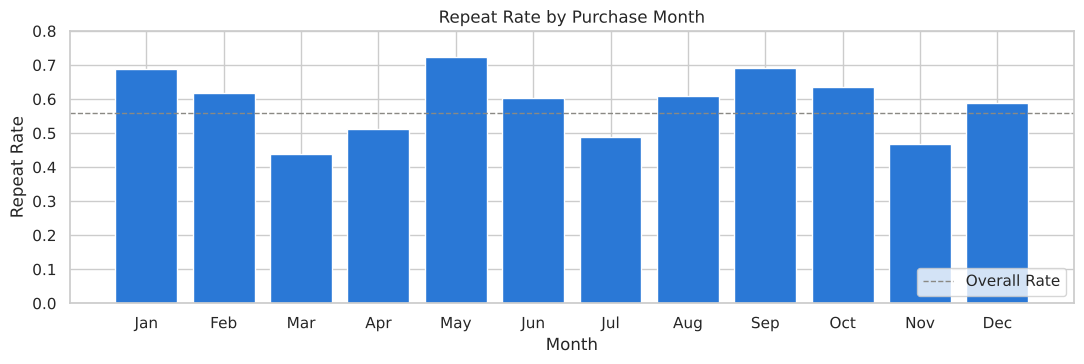

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Repeat Rate,0.69,0.62,0.44,0.51,0.72,0.60,0.49,0.61,0.69,0.64,0.47,0.59
Rows,444,260,876,442,196,311,874,525,436,680,884,541


In [14]:
CATEGORICAL_RAW = ["payment_type", "salesperson", "commercial_zone", "transport_method", "warehouse", "document_series"]

dates = pd.to_datetime(X["purchase_date"])
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
month = pd.DataFrame({"Repeat Rate": train.groupby(dates.dt.month)[TARGET].mean(),
                      "Rows": dates.dt.month.value_counts().sort_index()})
month.index = MONTHS

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.bar(month.index, month["Repeat Rate"], color=BLUE)
ax.axhline(y.mean(), color=GREY, ls="--", lw=1, label="Overall Rate")
ax.set(title="Repeat Rate by Purchase Month", xlabel="Month", ylabel="Repeat Rate", ylim=(0, 0.8))
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

display(month.T.style.format("{:.2f}", subset=pd.IndexSlice[["Repeat Rate"], :])
        .format("{:,.0f}", subset=pd.IndexSlice[["Rows"], :]).set_caption("Repeat Rate by Month"))

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Decisions for the categorical variables</b></p>

<table>
  <tr><th>Variable</th><th>Decision</th><th>Reason</th></tr>
  <tr><td>Payment Type, Salesperson</td><td>one hot, rare levels grouped</td><td>associated with the target (Task 1, Cram&eacute;r's V 0.23 and 0.20)</td></tr>
  <tr><td>Transport Method</td><td>one hot, rare levels grouped</td><td>80 levels, only 29 with at least 30 rows, so grouping avoids about 50 near empty columns</td></tr>
  <tr><td>Commercial Zone</td><td>one hot, rare levels grouped</td><td>weak and 97% one level, but cheap, and Task 3 can remove it</td></tr>
  <tr><td>Warehouse</td><td><b>drop</b></td><td>99.7% one level, almost constant, so it cannot separate the classes</td></tr>
  <tr><td>Document Series</td><td><b>drop</b></td><td>no association with the target in Task 1 (p = 0.97) and a proxy for the year in which a row was recorded</td></tr>
  <tr><td>Purchase Date, Month and Weekday</td><td>one hot</td><td>clear calendar pattern, with month repeat rates from 0.44 (March) to 0.72 (May) above and 0.50 on Saturday against 0.67 on Monday in Task 1</td></tr>
  <tr><td>Purchase Date, Year</td><td>not used</td><td>a clock feature that describes <i>when</i> a row was recorded, and test rows may lie in a period the model has not seen</td></tr>
</table>

<p><b>Encoding</b></p>

<p>The categorical variables are one hot encoded with a OneHotEncoder that groups levels with fewer than 30 training rows (<code>min_frequency=30</code>) and sends unknown levels to that group (<code>handle_unknown="infrequent_if_exist"</code>). The levels are anonymised names without order, so an ordinal code would invent an order, while one hot encoding makes no such assumption and stays small with at most a few dozen columns. Rare levels are merged into one infrequent column because their own repeat rate would rest on too few rows, and many of them are retired salespersons or delivery methods (Task 1, Section 10). Unseen levels, for example a new salesperson that appears only in validation or test data, go to the same infrequent column instead of raising an error, and the list of levels is learned in fit, that is from the training rows only.</p>

<p>Unlike the practicals, which use <code>drop="first"</code>, no level is dropped. The logistic regression in scikit-learn is regularised by default, so the redundancy of a full one hot block does not make it unstable, and the decision tree can then split on every level, including the first. Target encoding was not used, because it would need cross fitting inside each fold to avoid leaking the target and adds little for at most 31 levels per column after grouping.</p>

<p>The calendar parts are extracted by a rule. Month and Weekday are stored as text so that the encoder treats them as categories and not as numbers, since December is not twelve times January.</p>

</div>

In [15]:
def add_calendar(df):
    df = df.copy()
    when = pd.to_datetime(df["purchase_date"])
    as_text = lambda v: str(int(v)) if pd.notna(v) else np.nan   # a missing date stays missing
    df["month"] = when.dt.month.map(as_text).astype(object)
    df["weekday"] = when.dt.dayofweek.map(as_text).astype(object)
    return df

CATEGORICAL = ["payment_type", "salesperson", "commercial_zone", "transport_method", "month", "weekday"]
encoder_demo = OneHotEncoder(min_frequency=30, handle_unknown="infrequent_if_exist", sparse_output=False)
X_calendar = add_calendar(X_imputed)
encoder_demo.fit(X_calendar[CATEGORICAL].fillna("missing"))
pd.DataFrame({
    "Levels in Train": [X_calendar[c].nunique() for c in CATEGORICAL],
    "One Hot Columns": [len(cats) - (len(inf) - 1 if inf is not None else 0)
                        for cats, inf in zip(encoder_demo.categories_, encoder_demo.infrequent_categories_)],
}, index=[nice(c) for c in CATEGORICAL]).rename_axis("Variable")

,Levels in Train,One Hot Columns
Variable,,
Payment Type,9,7
Salesperson,9,8
Commercial Zone,5,4
Transport Method,80,31
Month,12,12
Weekday,7,7


<a id="clientes"></a>
<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h2>4. The optional table clientes.csv</h2>

<p>Task 1 (Section 6) reviewed the customer table and found that it joins to every train customer through the unique Customer ID, that Customer Type is completely empty, that Company Name and Address identify the customer, that Street, Island and City are about half empty, and that Postal Code, City and Municipality are far too detailed for about 600 customers. Customer Since Year is 2015 for 58% of customers, the first year of the data, so Customer Tenure Days measures the same thing more precisely. Task 1 named three candidates worth testing, Country or Region (repeat rate 0.566 for CT10 against 0.392 for CT5), whether Island is known (0.518 against 0.641) and Commercial Region with rare levels grouped.</p>

<p>The only new check here concerns the company names that occur more than once.</p>

</div>

In [16]:
dup_names = clientes[clientes["company_name"].duplicated(keep=False)]
print(f"Company Names shared by two Customer IDs: {dup_names['company_name'].nunique()}, "
      f"customers involved in train: {dup_names['customer_id'].isin(groups).sum()}")
(dup_names[["customer_id", "company_name", "commercial_region", "customer_since_year"]]
 .assign(in_train=dup_names["customer_id"].isin(groups)).rename(columns=nice).set_index("Customer ID"))

Company Names shared by two Customer IDs: 2, customers involved in train: 2


,Company Name,Commercial Region,Customer Since Year,in Train
Customer ID,,,,
255774,Excel Is Not A Database Ltd 384,Region RG17: We Will See Later,2021,True
714679,Excel Is Not A Database Ltd 384,Region RG17: We Will See Later,2017,True
652673,Excel Is Not A Database Ltd 664,Region RG33: We Will See Later,2015,False
821383,Excel Is Not A Database Ltd 664,NaN,2015,False


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight</b></p>

<p>Two company names occur under two Customer IDs each, but only one of these pairs appears in train and its two IDs differ in Customer Since Year, so they look like separate branches and are kept as separate customers, which affects 2 of 607 groups at most.</p>

<p><b>How the table would be integrated</b></p>

<p>If it is used, the table is joined by Customer ID as a many to one lookup, so every purchase receives the attributes of its customer. Only the three candidates of Task 1 enter, Country or Region and Commercial Region as categorical variables with rare levels grouped like all others, and Island Known as a 0/1 flag. A lookup fits nothing, so it is a rule. Every value is constant within a customer, so the decision whether to use the table needs a grouped test. Under a random split the model could recognise customers by their region and score well without learning anything that transfers to new customers. With folds grouped by Customer ID the held-out customers are unseen, so the table can only help if a region effect holds <i>across</i> customers. The comparison follows in Section 7.2.</p>

</div>

In [17]:
def join_clientes(df, table):
    attrs = table[["customer_id", "country_or_region", "commercial_region"]].copy()
    attrs["island_known"] = table["island"].notna().astype(int)
    out = df.merge(attrs, on="customer_id", how="left", validate="many_to_one")
    out.index = df.index
    return out

<a id="features"></a>
<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h2>5. Review of the supplied variables and additional features</h2>

<h3>5.1 Review of the supplied variables</h3>

<table>
  <tr><th>Variables</th><th>Decision</th><th>Reason</th></tr>
  <tr><td>ID</td><td>drop, kept outside the model as the row key for the submission</td><td>a row number without signal (Task 1, AUC 0.507)</td></tr>
  <tr><td>Customer ID</td><td>drop as a feature, used for joining the customer table and for grouping folds</td><td>an arbitrary code that would let a model memorise customers</td></tr>
  <tr><td>Random Noise</td><td>drop</td><td>pure noise by construction (Task 1, AUC 0.495)</td></tr>
  <tr><td>Total Payable, Gross Total</td><td>drop</td><td>exact linear combinations of other columns on 100% of rows (Total Payable = Net Total + Total Tax, Net Total = Gross Total &minus; discounts), so they add no information and make linear models unstable</td></tr>
  <tr><td>Warehouse, Document Series, Purchase Date</td><td>drop or replace</td><td>Section 3</td></tr>
  <tr><td>All other invoice, history and window columns</td><td>keep</td><td>selection is Task 3, and nothing here is invalid after the repair</td></tr>
</table>

<p>Highly correlated but not identical columns, such as counts and spends in the same window, are kept, because deciding between them is feature selection and belongs to Task 3.</p>

<h3>5.2 Additional features</h3>

<p>Every new feature is computed from the <b>same row only</b>, that is from information available at the moment of the purchase. Task 1 showed that the target means that the next purchase follows within 90 days, so any feature built from a customer's later rows would leak the target, and none is used.</p>

<table>
  <tr><th>Feature</th><th>Definition</th><th>Idea</th></tr>
  <tr><td>Mean Gap to Date</td><td>tenure / k</td><td>the customer's usual time between purchases including the current one, directly comparable with the 90 day window</td></tr>
  <tr><td>Typical Gap up to 90 Days</td><td>Mean Gap to Date &le; 90 and k &gt; 0</td><td>does the customer usually come back within 90 days?</td></tr>
  <tr><td>Purchases per Year</td><td>k / (tenure / 365.25)</td><td>purchase frequency independent of how long the customer has existed, with less drift over time than lifetime totals</td></tr>
  <tr><td>Last Gap vs Usual</td><td>Days Since Previous Purchase / max(Prior Mean Gap Days, 1), 1 if k &lt; 2</td><td>is the customer slowing down (above 1) or speeding up (below 1)?</td></tr>
  <tr><td>Share of 90 in 365 Days</td><td>Purchase Count 90 Days / Purchase Count 365 Days, 0 if none</td><td>recent activity relative to the year, where 0.25 means steady and higher means accelerating</td></tr>
  <tr><td>Spend per Purchase 365 Days</td><td>Spend 365 Days / Purchase Count 365 Days</td><td>typical basket of the last year</td></tr>
  <tr><td>Current vs Mean Value</td><td>Total Payable / Prior Mean Purchase Value, 1 if k = 0</td><td>is this purchase unusually large for this customer? (Total Payable is the amount the prior statistics are built from)</td></tr>
  <tr><td>Margin Rate</td><td>(Net Total &minus; Cost) / Net Total</td><td>profitability of the basket, scale free</td></tr>
  <tr><td>Zero Cost Flag</td><td>Cost = 0</td><td>repeats more often (Section 2.5)</td></tr>
  <tr><td>Discount Rate</td><td>(Line Discount + Global Discount) / Gross Total</td><td>how much the customer was discounted</td></tr>
  <tr><td>Shipping Flag</td><td>Shipping Cost &gt; 0</td><td>delivered or collected, 84% of rows have no shipping</td></tr>
  <tr><td>VAT Rate</td><td>Total Tax / Net Total</td><td>23% standard rate against reduced rates, a hint at product mix or region</td></tr>
  <tr><td>Value per Line</td><td>Net Total / Number of Lines</td><td>average value of an invoice line</td></tr>
</table>

<p>The function engineer adds these columns and removes the redundant ones. It is again a rule, and the only guards are against division by zero, since one row has two earlier purchases on the same day and therefore a mean gap of 0.</p>

</div>

In [18]:
def engineer(df):
    df = df.copy()
    k, ten = df["prior_purchase_count"], df["customer_tenure_days"]
    net = df["Total Liquido"]
    c365 = df["purchase_count_365d"]

    df["mean_gap_to_date"] = (ten / k).where(k > 0, 0.0)
    df["typical_gap_le_90"] = ((df["mean_gap_to_date"] <= 90) & (k > 0)).astype(int)
    df["purchases_per_year"] = (k / (ten / 365.25)).where(ten > 0, 0.0)
    df["last_gap_vs_usual"] = (df["days_since_previous_purchase"] / df["prior_mean_gap_days"].clip(lower=1)).where(k >= 2, 1.0)
    df["share_90_of_365"] = (df["purchase_count_90d"] / c365).where(c365 > 0, 0.0)
    df["spend_per_purchase_365d"] = (df["spend_365d"] / c365).where(c365 > 0, 0.0)
    df["current_vs_mean_value"] = (df["Total a Pagar"] / df["prior_mean_purchase_value"]).where(k > 0, 1.0)
    df["margin_rate"] = (net - df["Custo"]) / net
    df["zero_cost"] = (df["Custo"] == 0).astype(int)
    df["discount_rate"] = (df["Total Desc_ Linha"] + df["Total Desc_ Global"]) / df["Total Bruto"]
    df["has_shipping"] = (df["Total Portes"] > 0).astype(int)
    df["vat_rate"] = df["Total Imp_"] / net
    df["value_per_line"] = net / df["N_ Detalhes"]

    drop = ["ID", "random_noise", "Total a Pagar", "Total Bruto", "warehouse", "document_series", "purchase_date"]
    return df.drop(columns=[c for c in drop if c in df.columns])

ENGINEERED_CONTINUOUS = ["mean_gap_to_date", "purchases_per_year", "last_gap_vs_usual", "share_90_of_365",
                         "spend_per_purchase_365d", "current_vs_mean_value", "margin_rate", "discount_rate",
                         "vat_rate", "value_per_line"]
ENGINEERED_FLAGS = ["typical_gap_le_90", "zero_cost", "has_shipping"]

X_features = engineer(X_calendar)
print("Non-finite values:", int((~np.isfinite(X_features.select_dtypes("number"))).sum().sum()))
print("Rows with k ≥ 2 and a mean gap of 0:", int(((X_features["prior_purchase_count"] >= 2)
                                                   & (X_features["prior_mean_gap_days"] == 0)).sum()))

Non-finite values: 0
Rows with k ≥ 2 and a mean gap of 0: 1


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p>A first look at whether the new features carry signal uses the ROC AUC of each single feature against the target. A value of 0.5 means no signal and values below 0.5 mean a negative relationship, so the table shows max(AUC, 1 &minus; AUC) as the strength. The supplied features were ranked the same way in Task 1 (Section 8.1) and are not repeated here. This is a descriptive check on train, and the honest test of the whole block is the cross-validated comparison in Section 7.</p>

</div>

In [19]:
def auc_strength(col):
    auc = roc_auc_score(y, X_features[col])
    return max(auc, 1 - auc), "+" if auc >= 0.5 else "−"

strength = pd.DataFrame([(nice(c), *auc_strength(c)) for c in ENGINEERED_CONTINUOUS + ENGINEERED_FLAGS],
                        columns=["Feature", "AUC Strength", "Direction"])
strength.sort_values("AUC Strength", ascending=False).set_index("Feature")

,AUC Strength,Direction
Feature,,
Purchases per Year,0.744,+
Typical Gap up to 90 Days,0.692,+
Mean Gap to Date,0.658,−
Share of 90 in 365 Days,0.631,+
Discount Rate,0.624,+
Spend per Purchase 365 Days,0.600,+
Margin Rate,0.568,+
Value per Line,0.554,+
Last Gap vs Usual,0.543,−


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight</b></p>

<p>Two new features are among the strongest single features, while several others carry little signal on their own. Purchases per Year (0.744) is almost as strong as Purchase Count 365 Days, the best supplied feature in Task 1 (0.753), and Typical Gap up to 90 Days (0.692) turns the 90 day definition of the target into a feature. Discount Rate (0.624) is stronger than every invoice column in Task 1, which lie between 0.48 and 0.55 with only Line Discount at 0.611.</p>

<p>Current vs Mean Value, VAT Rate, Shipping Flag and Zero Cost Flag are close to 0.5 on their own. They are kept as candidates because they may act in combination (Task 1 found that the current amount matters for infrequent customers only), and Task 3 decides. Univariate strength is not the same as added value, since Purchases per Year largely re-expresses the counts that are already there, and Section 7.2 measures what the block adds to the full feature set.</p>

</div>

<a id="scaling"></a>
<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h2>6. Scaling</h2>

<h3>6.1 log1p for the skewed columns</h3>

<p>Task 1 found a skewness between 4 and 6 for most amounts and counts. The table compares the skewness before and after log1p, that is log(1 + x), which is defined at 0 and monotonic, so the order of the values and tree splits are unaffected.</p>

</div>

In [20]:
LOG_COLUMNS = [
    # invoice amounts and counts
    "Total Liquido", "Total Imp_", "Total Portes", "Total Desc_ Global", "Total Desc_ Linha", "Custo",
    "N_ Detalhes", "invoice_count_current_purchase",
    # history
    "days_since_previous_purchase", "customer_tenure_days", "prior_purchase_count", "prior_total_spend",
    "prior_mean_purchase_value", "prior_std_purchase_value", "prior_min_purchase_value",
    "prior_max_purchase_value", "prior_mean_gap_days", "prior_std_gap_days",
    # rolling windows
    "purchase_count_30d", "spend_30d", "purchase_count_90d", "spend_90d", "purchase_count_180d", "spend_180d",
    "purchase_count_365d", "spend_365d",
    # engineered ratios with a long right tail
    "mean_gap_to_date", "purchases_per_year", "last_gap_vs_usual", "spend_per_purchase_365d",
    "current_vs_mean_value", "value_per_line",
]
PLAIN_COLUMNS = ["share_90_of_365", "margin_rate", "discount_rate", "vat_rate"]   # bounded ratios, no log
FLAGS = ["is_first_purchase", "has_gap_history"] + ENGINEERED_FLAGS

assert (X_features[LOG_COLUMNS] >= 0).all().all(), "log1p needs non-negative inputs"
skew = pd.DataFrame({"Skew Raw": X_features[LOG_COLUMNS].skew(),
                     "Skew after log1p": np.log1p(X_features[LOG_COLUMNS]).skew()})
print(f"Median absolute skew: raw {skew['Skew Raw'].abs().median():.2f}, after log1p {skew['Skew after log1p'].abs().median():.2f}")
skew.sort_values("Skew Raw", ascending=False).head(10).rename(index=nice).rename_axis("Column")

Median absolute skew: raw 4.38, after log1p 1.07


,Skew Raw,Skew after log1p
Column,,
Last Gap vs Usual,45.557,2.257
Global Discount,27.458,9.276
Shipping Cost,19.549,2.265
Current vs Mean Value,15.349,1.139
Purchases per Year,10.700,0.385
Value per Line,10.239,1.253
Prior Mean Gap Days,9.004,-1.040
Prior Std of Gap Days,7.868,-0.731
Mean Gap to Date,7.719,-1.309


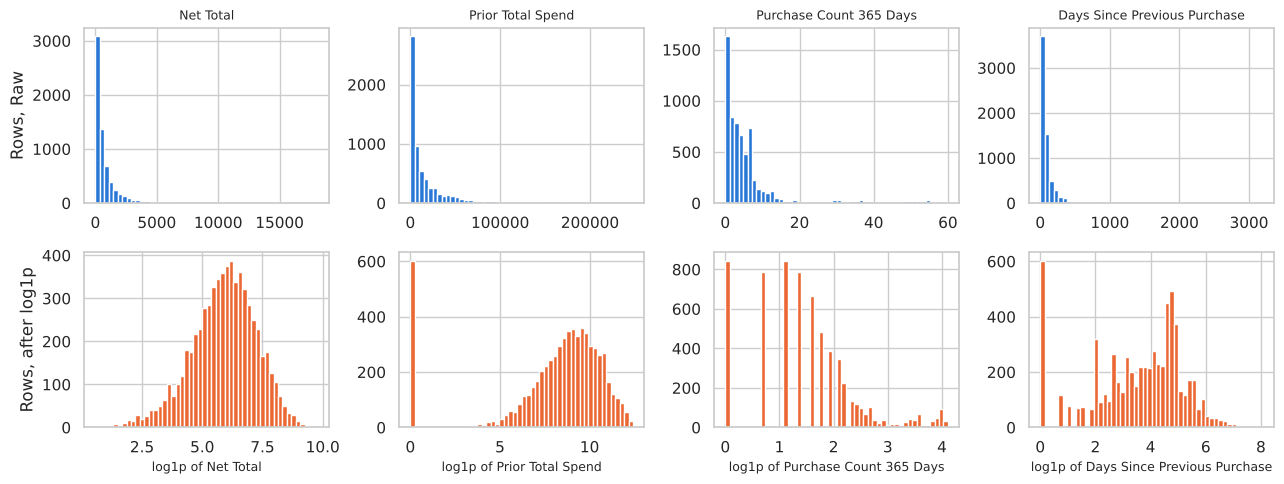

In [21]:
show = ["Total Liquido", "prior_total_spend", "purchase_count_365d", "days_since_previous_purchase"]
fig, axes = plt.subplots(2, 4, figsize=(13, 5))
for j, col in enumerate(show):
    axes[0, j].hist(X_features[col], bins=50, color=BLUE)
    axes[0, j].set_title(nice(col), fontsize=9)
    axes[1, j].hist(np.log1p(X_features[col]), bins=50, color=ORANGE)
    axes[1, j].set_xlabel(f"log1p of {nice(col)}", fontsize=9)
axes[0, 0].set_ylabel("Rows, Raw")
axes[1, 0].set_ylabel("Rows, after log1p")
plt.tight_layout()
plt.show()

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight</b></p>

<p>log1p brings the median absolute skewness of the 32 skewed columns down from 4.38 to 1.07, and the histograms turn from a spike at zero with a long tail into roughly symmetric shapes. A few columns stay skewed after the transform, most clearly Global Discount (9.3), because almost all of their values are zero.</p>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>6.2 Which scaler?</h3>

<p>Scaling matters only for models that compare feature magnitudes, such as regularised linear models (the penalty treats every coefficient alike), distance based models (k-NN, SVM) and neural networks. Decision trees split on thresholds, so any transformation that keeps the order of the values, such as log1p or a scaler, does not change them. Section 7.2 runs the cleaned pipeline with three scalers (none, standard, robust), each with and without log1p, under the same grouped 5-fold cross-validation.</p>

<p>The decision taken there is log1p on the skewed columns followed by a StandardScaler on all continuous columns, while the 0/1 flags and one hot columns are not scaled. The reasons are given with the numbers in Section 7.2.</p>

</div>

<a id="pipeline"></a>
<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h2>7. Reproducible pre-processing without test.csv</h2>

<h3>7.1 Assembly</h3>

<p>The last sentence of the task asks that every pre-processing decision is reproducible and that test.csv never helps to fit a transformation. As in the Week 4 practical, all steps are collected in one function, fold matrices, which receives a training frame and a test frame and returns the two finished matrices. Every fitted step learns from the training frame only, and the test frame only ever reaches a transform. The recipe names the options that the comparisons below vary, and RECIPE holds the final choice.</p>

<table>
  <tr><th>Step</th><th>Kind</th><th>What It Does</th></tr>
  <tr><td>1. Repair</td><td>rule</td><td>placeholder codes, sign flips, inflated values, recomputation through identities (Section 2.4)</td></tr>
  <tr><td>2. Fill History</td><td><b>fitted</b></td><td>two training medians, structural zeros and two indicators (Section 2.7)</td></tr>
  <tr><td>3. Calendar, Customer Table, Features</td><td>rule</td><td>Month and Weekday (Section 3), optional join of three customer attributes (Section 4), engineered features and dropped columns (Section 5)</td></tr>
  <tr><td>4. Fill Missing</td><td><b>fitted</b></td><td>own level "missing" for categorical gaps, training median as a safety net for completely empty rows</td></tr>
  <tr><td>5. Encode</td><td><b>fitted</b></td><td>one hot with rare levels grouped, categories learned from the training frame (Section 3)</td></tr>
  <tr><td>6. log1p</td><td>rule</td><td>skewed continuous columns (Section 6)</td></tr>
  <tr><td>7. Scale</td><td><b>fitted</b></td><td>StandardScaler on the continuous columns with the training mean and standard deviation, flags and one hot columns unscaled (Section 6)</td></tr>
</table>

<p>Customer ID passes through the rule steps because the join needs it, and it never enters the matrix because it is not listed among the model columns.</p>

</div>

In [22]:
# One encoder and one scaler per call, refitted on every training frame.
scalers = {"none": None, "standard": StandardScaler, "robust": RobustScaler}
RECIPE = {"clientes": False, "engineered": True, "log1p": True, "scaler": "standard"}


# Return (A_train, A_test, names) for ONE split, every fitted step fitted on `train`.
def fold_matrices(train, test, recipe=RECIPE):
    continuous = [c for c in LOG_COLUMNS + PLAIN_COLUMNS if recipe["engineered"] or c not in ENGINEERED_CONTINUOUS]
    flags = FLAGS if recipe["engineered"] else ["is_first_purchase", "has_gap_history"]
    categorical = list(CATEGORICAL)

    # 1. REPAIR, a rule that reads one row at a time.
    train, test = repair(train), repair(test)

    # 2. FILL HISTORY with the two values learned from the training rows.
    values = history_fill_values(train)
    train, test = fill_history(train, values), fill_history(test, values)

    # 3. CALENDAR, optional CUSTOMER TABLE and FEATURES, all rules.
    train, test = add_calendar(train), add_calendar(test)
    if recipe["clientes"]:
        train, test = join_clientes(train, clientes), join_clientes(test, clientes)
        categorical += ["country_or_region", "commercial_region"]
        flags = flags + ["island_known"]
    train, test = engineer(train), engineer(test)

    # 4. FILL MISSING. The median does nothing on rows that passed steps 1 to 3; it is a safety
    #    net for rows whose features are completely empty, which still need a prediction.
    train, test = fill_missing(train, test, [
        (continuous, SimpleImputer(strategy="median")),
        (categorical, SimpleImputer(strategy="constant", fill_value="missing")),
    ])

    # 5. ENCODE, with the categories of the training rows.
    encoder = OneHotEncoder(min_frequency=30, handle_unknown="infrequent_if_exist", sparse_output=False)
    cat_train = encoder.fit_transform(train[categorical])
    cat_test = encoder.transform(test[categorical])

    # 6. log1p on the skewed columns. It fits nothing.
    log_cols = [c for c in continuous if c in LOG_COLUMNS] if recipe["log1p"] else []
    ordered = log_cols + [c for c in continuous if c not in log_cols]
    num_train = train[ordered].to_numpy(dtype=float)
    num_test = test[ordered].to_numpy(dtype=float)
    num_train[:, :len(log_cols)] = np.log1p(num_train[:, :len(log_cols)])
    num_test[:, :len(log_cols)] = np.log1p(num_test[:, :len(log_cols)])

    # 7. SCALE with the centre and spread of the training rows; flags and one-hot stay 0/1.
    make = scalers[recipe["scaler"]]
    if make is not None:
        fitted = make().fit(num_train)
        num_train, num_test = fitted.transform(num_train), fitted.transform(num_test)

    names = ordered + flags + list(encoder.get_feature_names_out(categorical))
    return (np.hstack([num_train, train[flags].to_numpy(dtype=float), cat_train]),
            np.hstack([num_test, test[flags].to_numpy(dtype=float), cat_test]),
            np.asarray(names))

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p>A <b>naive baseline</b> serves as comparison. It uses the supplied numeric columns with a median fill and a standard scaler and one hot encodes the six raw categorical columns, without repair, structural handling or engineered features and with the 1e9 codes left in place. It shows what the cleaning is worth.</p>

</div>

In [23]:
NAIVE_NUMERIC = ["Total a Pagar", "Total Bruto", "Total Liquido", "Total Imp_", "Total Portes", "Total Desc_ Global",
                 "Total Desc_ Linha", "Custo", "N_ Detalhes", "invoice_count_current_purchase",
                 "days_since_previous_purchase", "customer_tenure_days", "prior_purchase_count", "prior_total_spend",
                 "prior_mean_purchase_value", "prior_std_purchase_value", "prior_min_purchase_value",
                 "prior_max_purchase_value", "prior_mean_gap_days", "prior_std_gap_days", "purchase_count_30d",
                 "spend_30d", "purchase_count_90d", "spend_90d", "purchase_count_180d", "spend_180d",
                 "purchase_count_365d", "spend_365d"]


# The naive baseline: median and own-level fill, one-hot, standard scaling, nothing else.
def naive_matrices(train, test):
    train, test = fill_missing(train, test, [
        (NAIVE_NUMERIC, SimpleImputer(strategy="median")),
        (CATEGORICAL_RAW, SimpleImputer(strategy="constant", fill_value="missing")),
    ])
    scaler = StandardScaler().fit(train[NAIVE_NUMERIC])
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(train[CATEGORICAL_RAW])
    return (np.hstack([scaler.transform(train[NAIVE_NUMERIC]), encoder.transform(train[CATEGORICAL_RAW])]),
            np.hstack([scaler.transform(test[NAIVE_NUMERIC]), encoder.transform(test[CATEGORICAL_RAW])]))

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>7.2 Held-out comparison of the decisions</h3>

<p>Held-out AUC scores a preparation on the five customer grouped folds and is the counterpart of held-out F1 in the practicals. For every fold it prepares the training and the held-out rows, fits the model on the training rows and scores the held-out rows, so nothing learned from a held-out fold can reach the pre-processing. Each variant is scored with both reference models on the same five folds.</p>

</div>

In [24]:
# Five folds, stratified by the target as the lecture recommends for classification, and grouped
# by customer so that no customer is on both sides of a split.
SPLITS = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE).split(X, y, groups))


# The two models of the practicals. The tree is limited to depth 5 so it cannot memorise the
# training rows. Choosing and tuning the final model is Task 4.
def reference_models():
    return {
        "Logistic Regression": LogisticRegression(max_iter=2000),
        "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    }


# ROC AUC on the held-out rows of every split, one score per split.
def held_out_auc(prepare, model, frame=X, splits=SPLITS):
    scores = []
    for train_rows, test_rows in splits:
        A_train, A_test = prepare(frame.iloc[train_rows], frame.iloc[test_rows])[:2]
        fitted = clone(model).fit(A_train, y.iloc[train_rows])
        scores.append(roc_auc_score(y.iloc[test_rows], fitted.predict_proba(A_test)[:, 1]))
    return np.array(scores)


def with_recipe(**changes):
    return lambda train, test: fold_matrices(train, test, {**RECIPE, **changes})


variants = {
    "A  Naive Baseline": naive_matrices,
    "B  Cleaned (Repair, Imputation, Encoding, log1p and Standard Scaling)": with_recipe(engineered=False),
    "C  B plus Engineered Features": with_recipe(),
    "D  C plus Customer Table": with_recipe(clientes=True),
}
fold_scores = {(name, model_name): held_out_auc(prepare, model)
               for name, prepare in variants.items() for model_name, model in reference_models().items()}
(pd.Series({key: f"{s.mean():.4f} ± {s.std():.4f}" for key, s in fold_scores.items()}).unstack()
 .rename_axis(index="Variant", columns="ROC AUC by Model"))

ROC AUC by Model,Decision Tree,Logistic Regression
Variant,,
A Naive Baseline,0.7487 ± 0.0274,0.7749 ± 0.0205
"B Cleaned (Repair, Imputation, Encoding, log1p and Standard Scaling)",0.7490 ± 0.0262,0.7900 ± 0.0213
C B plus Engineered Features,0.7540 ± 0.0249,0.7924 ± 0.0208
D C plus Customer Table,0.7540 ± 0.0249,0.7915 ± 0.0212


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p>The &plusmn; spread mostly reflects which customers land in which fold, and every variant uses the same five folds. The fair comparison is therefore <b>paired</b>, as in the practicals and the lecture, looking at the change in AUC on the same fold, at how many of the five folds a step helps and at the p value of a paired t-test on the five folds (below 0.05 means the difference is unlikely to be chance).</p>

</div>

In [25]:
names = list(variants)
paired = {}
for model_name in reference_models():
    for before, after in zip(names, names[1:]):
        diff = fold_scores[(after, model_name)] - fold_scores[(before, model_name)]
        p = ttest_rel(fold_scores[(after, model_name)], fold_scores[(before, model_name)]).pvalue
        paired[(f"{after[:1]} vs {before[:1]}", model_name)] = f"{diff.mean():+.4f}  (better in {(diff > 0).sum()}/5 folds, p = {p:.3f})"
pd.Series(paired).unstack().rename_axis(index="Comparison", columns="Change in ROC AUC by Model")

Change in ROC AUC by Model,Decision Tree,Logistic Regression
Comparison,,
B vs A,"+0.0002 (better in 3/5 folds, p = 0.958)","+0.0151 (better in 5/5 folds, p = 0.010)"
C vs B,"+0.0051 (better in 3/5 folds, p = 0.290)","+0.0024 (better in 5/5 folds, p = 0.007)"
D vs C,"+0.0000 (better in 0/5 folds, p = nan)","-0.0009 (better in 2/5 folds, p = 0.601)"


In [26]:
scaling = {}
for scaler in ["none", "standard", "robust"]:
    for log in [False, True]:
        s = held_out_auc(with_recipe(log1p=log, scaler=scaler), LogisticRegression(max_iter=2000))
        scaling[(scaler.capitalize(), "log1p" if log else "Raw")] = f"{s.mean():.4f} ± {s.std():.4f}"
s = held_out_auc(with_recipe(log1p=False, scaler="none"), reference_models()["Decision Tree"])
print(f"Decision tree without log1p and without scaling: {s.mean():.4f} ± {s.std():.4f} (row C above uses log1p and scaling)")
pd.Series(scaling).unstack().rename_axis(index="Scaler (Logistic Regression)", columns="Numeric Columns")

Decision tree without log1p and without scaling: 0.7540 ± 0.0249 (row C above uses log1p and scaling)


Numeric Columns,Raw,log1p
Scaler (Logistic Regression),,
None,0.7586 ± 0.0214,0.7921 ± 0.0204
Robust,0.7905 ± 0.0220,0.7919 ± 0.0209
Standard,0.7896 ± 0.0217,0.7924 ± 0.0208


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight</b></p>

<p>Cleaning pays off for the logistic regression. Repair, structural imputation, rare level grouping and log1p raise its AUC from 0.775 to 0.790, the gain appears in all five folds and the paired t-test gives p = 0.010. The naive baseline keeps the redundant amounts and the 1e9 codes, which a linear model reads as enormous real values. The decision tree stays at 0.749 (p = 0.958), because a tree only asks whether a value lies above or below a threshold, so a 1e9 code is just a very large value for it and changes little.</p>

<p>The engineered features add a small but consistent gain on top. The logistic regression improves from 0.790 to 0.792 in all five folds (p = 0.007), and the decision tree from 0.749 to 0.754, although that gain is not significant (3 of 5 folds, p = 0.290). Most new features re-express information that the supplied history columns already contain, which explains why the gain is small. They are kept, and Task 3 decides whether each one stays by comparing it with the supplied columns it overlaps with.</p>

<p>The customer table is not integrated. For the logistic regression D against C lowers the AUC by 0.001 and helps in only 2 of 5 folds (p = 0.601). The decision tree gives exactly the same scores with and without the table, because none of its splits uses the three customer columns, so the difference is 0 on every fold and the t-test cannot be computed (p = nan). With customer grouped folds the differences seen in Task 1 (Country CT5 at 0.39 against 0.57) do not transfer to unseen customers. CT5 covers only 30 customers, and whatever separates them is already visible in their purchase behaviour, so constant per customer columns would mainly give a model a way to recognise customers. The join stays in the code as an option of the recipe, so the decision remains reproducible.</p>

<p>For the logistic regression the decisive step is log1p, which raises the AUC without a scaler from 0.759 to 0.792 by turning heavy tailed amounts into roughly symmetric distributions on which a linear effect is plausible. Once the columns are logged the scaler hardly matters (0.792 for none, standard and robust). The pre-processing still uses a StandardScaler, because the regularisation of the logistic regression is only fair when all features are on one scale, models such as k-NN or SVM that Task 4 may try depend on it directly, and the solver converges faster. After log1p there is no extreme tail left, so mean and standard deviation are meaningful and a RobustScaler offers no advantage. The 0/1 flags and one hot columns stay unscaled, since they already share a 0 to 1 scale and stay interpretable. The decision tree scores exactly 0.754 with and without log1p and scaling, as expected for a model that only compares values with thresholds, so the same pre-processing serves both models.</p>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>7.3 Fit on training rows, transform unseen rows</h3>

<p>The fit and transform discipline is demonstrated on a split that imitates the final situation. The pre-processing is fitted on 80% of the customers and then only applied to the other 20%, whose customers it has never seen. This is exactly what Task 4 does with train.csv and test.csv.</p>

</div>

In [27]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
fit_idx, new_idx = next(splitter.split(X, y, groups))
X_fit, X_new = X.iloc[fit_idx], X.iloc[new_idx]

Z_fit, Z_new, names = fold_matrices(X_fit, X_new)   # fits on X_fit, only transforms X_new
fit_values = history_fill_values(repair(X_fit))
print(f"Customers: {groups.iloc[fit_idx].nunique()} for fitting, {groups.iloc[new_idx].nunique()} unseen, overlap "
      f"{len(set(groups.iloc[fit_idx]) & set(groups.iloc[new_idx]))}")
print(f"Matrix shapes: fit {Z_fit.shape}, unseen {Z_new.shape}; same columns: {Z_fit.shape[1] == Z_new.shape[1]}")
print(f"Missing or infinite values: fit {int((~np.isfinite(Z_fit)).sum())}, unseen {int((~np.isfinite(Z_new)).sum())}")
print("Learned only from the fitting rows:",
      f"median recency {fit_values['days_median']:.0f} days,",
      f"max / mean {fit_values['max_to_mean']:.2f}")
scaled_part = [i for i, n in enumerate(names) if n in LOG_COLUMNS + PLAIN_COLUMNS]
print(f"Scaled columns: mean {Z_fit[:, scaled_part].mean():.3f} / std {Z_fit[:, scaled_part].std():.3f} on the fitting rows, "
      f"mean {Z_new[:, scaled_part].mean():.3f} / std {Z_new[:, scaled_part].std():.3f} on the unseen rows")

Customers: 485 for fitting, 122 unseen, overlap 0
Matrix shapes: fit (5326, 107), unseen (1143, 107); same columns: True
Missing or infinite values: fit 0, unseen 0
Learned only from the fitting rows: median recency 50 days, max / mean 2.68
Scaled columns: mean 0.000 / std 1.000 on the fitting rows, mean -0.058 / std 0.951 on the unseen rows


In [28]:
unseen_levels = {c: sorted(set(X_new[c].dropna()) - set(X_fit[c].dropna()))
                 for c in ["payment_type", "salesperson", "transport_method", "commercial_zone"]}
display(pd.DataFrame({
    "Unseen Levels": {nice(c): len(levels) for c, levels in unseen_levels.items()},
    "Examples": {nice(c): ", ".join(levels[:4]) for c, levels in unseen_levels.items()},
}).rename_axis("Variable"))
print("They are encoded in the infrequent column of their variable, with no error and no extra column.")

,Unseen Levels,Examples
Variable,,
Payment Type,1,Maybe Tomorrow Payment 4
Salesperson,0,
Transport Method,8,"Maybe Tomorrow Delivery 15, Maybe Tomorrow Delivery 16, Maybe Tomorrow Delivery 2, Maybe Tomorrow Delivery 20"
Commercial Zone,1,Decorative Dashboard Zone 6


They are encoded in the infrequent column of their variable, with no error and no extra column.


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight</b></p>

<p>The pipeline behaves as intended on unseen customers. It is fitted on 485 customers and applied to 122 others without overlap, both matrices have the same 107 columns and contain no missing or infinite values, and the imputation values (median recency 50 days, max / mean ratio 2.68) come from the fitting rows only. The scaled columns have mean 0 and standard deviation 1 on the fitting rows and stay close to that on the unseen rows (&minus;0.058 and 0.951). One Payment Type, eight Transport Method and one Commercial Zone level occur only in the unseen rows and are mapped to the infrequent column without an error.</p>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p>Train contained 65 completely empty rows, so test.csv may contain such rows as well, and each of them still needs a prediction. The check below takes a training row, empties every feature as in those 65 rows and passes it through the fitted pipeline.</p>

</div>

In [29]:
empty_row = X_new.iloc[[0]].copy()
empty_row[[c for c in empty_row.columns if c not in IDENTIFIERS]] = np.nan
Z_empty = fold_matrices(X_fit, empty_row)[1]
print(f"Empty row after transform: {Z_empty.shape[1]} columns, missing or infinite values: {int((~np.isfinite(Z_empty)).sum())}")

Empty row after transform: 107 columns, missing or infinite values: 0


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight</b></p>

<p>A row without any feature passes through the pipeline without an error and receives a complete row of values. The history statistics fall back to the training medians, the categorical variables go to their missing level, the calendar parts (which never miss in train) go to the infrequent column, and the row can therefore be scored like any other test row.</p>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p>Finally, the pre-processing is fitted on the full cleaned training data to show the design matrix that Task 4 starts from.</p>

</div>

In [30]:
A_train, _, final_names = fold_matrices(X, X)   # only the training matrix is used here
Z_train = pd.DataFrame(A_train, columns=final_names, index=X.index)
blocks = pd.Series({
    "Continuous, log1p and Standardised": len([c for c in Z_train.columns if c in LOG_COLUMNS]),
    "Continuous, Standardised": len([c for c in Z_train.columns if c in PLAIN_COLUMNS]),
    "Indicator Flags (0/1)": len([c for c in Z_train.columns if c in FLAGS]),
    "One Hot Columns": Z_train.shape[1] - len([c for c in Z_train.columns if c in LOG_COLUMNS + PLAIN_COLUMNS + FLAGS]),
}, name="Columns").rename_axis("Block")
print(f"Design matrix: {Z_train.shape[0]:,} rows x {Z_train.shape[1]} columns, "
      f"missing {int(Z_train.isna().sum().sum())}")
blocks.to_frame()

Design matrix: 6,469 rows x 110 columns, missing 0


,Columns
Block,
"Continuous, log1p and Standardised",32
"Continuous, Standardised",4
Indicator Flags (0/1),5
One Hot Columns,69


In [31]:
Z_train.head().rename(columns=nice)

,Net Total,Total Tax,Shipping Cost,Global Discount,Line Discount,Cost,Number of Lines,Invoices in Purchase,Days Since Previous Purchase,Customer Tenure Days,Prior Purchase Count,Prior Total Spend,Prior Mean Purchase Value,Prior Std of Purchase Value,Prior Min Purchase Value,Prior Max Purchase Value,Prior Mean Gap Days,Prior Std of Gap Days,Purchase Count 30 Days,Spend 30 Days,Purchase Count 90 Days,Spend 90 Days,Purchase Count 180 Days,Spend 180 Days,Purchase Count 365 Days,Spend 365 Days,Mean Gap to Date,Purchases per Year,Last Gap vs Usual,Spend per Purchase 365 Days,Current vs Mean Value,Value per Line,Share of 90 in 365 Days,Margin Rate,Discount Rate,VAT Rate,First Purchase Flag,Gap History Flag,Typical Gap up to 90 Days,Zero Cost Flag,Shipping Flag,Payment Type Maybe Tomorrow Payment 10,Payment Type Maybe Tomorrow Payment 12,Payment Type Maybe Tomorrow Payment 7,Payment Type Maybe Tomorrow Payment 8,Payment Type Maybe Tomorrow Payment 9,Payment Type Missing,Payment Type Infrequent,Salesperson VLOOKUP Master 1,Salesperson VLOOKUP Master 2,Salesperson VLOOKUP Master 3,Salesperson VLOOKUP Master 4,Salesperson VLOOKUP Master 7,Salesperson VLOOKUP Master 9,Salesperson Missing,Salesperson Infrequent,Commercial Zone Decorative Dashboard Zone 2,Commercial Zone Decorative Dashboard Zone 3,Commercial Zone Decorative Dashboard Zone 4,Commercial Zone Infrequent,Transport Method Maybe Tomorrow Delivery 10,Transport Method Maybe Tomorrow Delivery 11,Transport Method Maybe Tomorrow Delivery 22,Transport Method Maybe Tomorrow Delivery 32,Transport Method Maybe Tomorrow Delivery 33,Transport Method Maybe Tomorrow Delivery 35,Transport Method Maybe Tomorrow Delivery 36,Transport Method Maybe Tomorrow Delivery 39,Transport Method Maybe Tomorrow Delivery 40,Transport Method Maybe Tomorrow Delivery 41,Transport Method Maybe Tomorrow Delivery 42,Transport Method Maybe Tomorrow Delivery 44,Transport Method Maybe Tomorrow Delivery 45,Transport Method Maybe Tomorrow Delivery 46,Transport Method Maybe Tomorrow Delivery 47,Transport Method Maybe Tomorrow Delivery 49,Transport Method Maybe Tomorrow Delivery 51,Transport Method Maybe Tomorrow Delivery 53,Transport Method Maybe Tomorrow Delivery 56,Transport Method Maybe Tomorrow Delivery 59,Transport Method Maybe Tomorrow Delivery 61,Transport Method Maybe Tomorrow Delivery 66,Transport Method Maybe Tomorrow Delivery 68,Transport Method Maybe Tomorrow Delivery 71,Transport Method Maybe Tomorrow Delivery 72,Transport Method Maybe Tomorrow Delivery 73,Transport Method Maybe Tomorrow Delivery 74,Transport Method Maybe Tomorrow Delivery 78,Transport Method Maybe Tomorrow Delivery 80,Transport Method Missing,Transport Method Infrequent,Month 1,Month 10,Month 11,Month 12,Month 2,Month 3,Month 4,Month 5,Month 6,Month 7,Month 8,Month 9,Weekday 0,Weekday 1,Weekday 2,Weekday 4,Weekday 5,Weekday 6,Weekday Infrequent
0,0.180,0.306,-0.424,-0.121,0.649,0.177,-0.766,-0.227,0.512,-0.544,-0.960,-0.435,0.111,-0.190,1.148,-0.203,0.208,-1.700,-0.626,-0.681,0.079,0.539,0.048,0.289,-0.435,-0.053,0.209,0.190,0.656,0.179,0.375,1.087,1.012,0.453,0.009,0.308,0.000,1.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000
1,0.593,0.680,-0.424,-0.121,0.435,0.776,0.875,-0.227,1.175,0.164,-0.439,0.245,0.668,0.908,0.411,0.686,0.591,0.957,-0.626,-0.681,-0.882,-1.072,-1.273,-1.771,0.103,0.308,0.646,-0.380,1.292,0.338,-0.283,-0.331,-0.785,-0.565,-0.513,0.308,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>How Task 4 uses this</b></p>

<p>Task 4 calls the same function. During cross-validation grouped by Customer ID and during tuning it is called once per split, so every split learns its own fill values, categories and scaling statistics. For the submission it is called once as <code>fold_matrices(train_clean, test)</code>, where train_clean holds the 6,469 cleaned rows of train.csv. Everything is fitted on train_clean, test.csv only passes through the transforms, and no row of test.csv is dropped.</p>

</div>

<a id="summary"></a>
<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h2>8. Summary of decisions</h2>

<table>
  <tr><th>#</th><th>Issue (Task 1)</th><th>Extent</th><th>Decision</th><th>Kind</th></tr>
  <tr><td>1</td><td>Completely empty rows</td><td>65 rows</td><td>dropped from training only, test rows are never dropped and an empty test row is filled by the median safety net</td><td>train only filter</td></tr>
  <tr><td>2</td><td>Placeholder 1e9, flipped signs and inflated values in Prior Mean Purchase Value</td><td>16 + 16 + 46 rows, plus 194 gaps</td><td>recomputed as T / k on every row</td><td>rule</td></tr>
  <tr><td>3</td><td>&minus;4 day codes and missing recency or mean gap</td><td>16 + 16 codes, about 195 gaps each</td><td>recomputed from gap = (tenure &minus; days) / (k &minus; 1), 8 rows imputed with the training median</td><td>rule and fitted</td></tr>
  <tr><td>4</td><td>Spend 365 Days with codes, sign flips, values above lifetime spend and gaps</td><td>15 + 15 + 39 + 195 rows</td><td>sign restored, exact identities, otherwise rate estimate (15% median error against 48% for a median)</td><td>rule</td></tr>
  <tr><td>5</td><td>Inflated maxima</td><td>45 rows</td><td>max = total when k = 1, otherwise training median of max / mean, bounded</td><td>rule and fitted</td></tr>
  <tr><td>6</td><td>Structurally undefined history statistics</td><td>603 / 1,048 / 1,413 rows</td><td>constant 0 plus First Purchase Flag and Gap History Flag</td><td>rule</td></tr>
  <tr><td>7</td><td>Missing categorical values</td><td>about 195 per column</td><td>own level "missing"</td><td>rule</td></tr>
  <tr><td>8</td><td>Extreme but consistent values, sales below cost</td><td>heavy customers, 39 rows</td><td>kept, tail compressed by log1p, zero cost as a flag</td><td>rule</td></tr>
  <tr><td>9</td><td>Categorical variables</td><td>4 kept, Warehouse and Document Series dropped</td><td>one hot, levels with fewer than 30 rows grouped, unseen levels to infrequent, Month and Weekday added</td><td>fitted</td></tr>
  <tr><td>10</td><td>Exactly redundant amounts, identifiers, noise</td><td>Total Payable, Gross Total, ID, Customer ID, Random Noise</td><td>dropped (ID kept for the submission, Customer ID for grouping)</td><td>rule</td></tr>
  <tr><td>11</td><td>Additional features</td><td>13 new</td><td>row wise only, no information from later rows, selection in Task 3</td><td>rule</td></tr>
  <tr><td>12</td><td>Skew and scaling</td><td>32 skewed continuous columns</td><td>log1p and StandardScaler, flags and one hot columns unscaled</td><td>rule and fitted</td></tr>
  <tr><td>13</td><td>Customer table clientes.csv</td><td>3 candidate columns tested</td><td><b>not integrated</b>, no gain on unseen customers</td><td>decision by grouped CV</td></tr>
</table>

<p><b>Result</b></p>

<p>6,469 training rows from 607 customers become a complete numeric matrix of 110 columns without missing or infinite values. Every rule is a plain function of a single row, and every learned quantity (two imputation values, category lists, scaling statistics) sits inside fold matrices and is fitted on training rows only. test.csv was not read in this notebook, and in Task 4 it only passes through the transforms.</p>

</div>